Lets analyze from retail industry
Background
The data is from , Kaggle.
Daily transaction records of Instax cameras, films, and accessories (2022-2025) form the brand Fujifilm Instax TM.




Import EVERYTHING

In [ ]:
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bertnardomariouskono/fujifilm-instax-sales-transaction-data-synthetic")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fujifilm-instax-sales-transaction-data-synthetic' dataset.
Path to dataset files: /kaggle/input/fujifilm-instax-sales-transaction-data-synthetic


In [ ]:
import os

os.listdir(path)

['instax_sales_transaction_data.csv']

In [ ]:
retail = pd.read_csv("/root/.cache/kagglehub/datasets/bertnardomariouskono/fujifilm-instax-sales-transaction-data-synthetic/versions/1/instax_sales_transaction_data.csv")

In [ ]:
retail.head(3)

,Tanggal,Tahun,Bulan,Hari,Kategori,Nama_Produk,Lokasi_Toko,Metode_Bayar,Harga_Satuan,Qty,Diskon_IDR,Total_Penjualan
0,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Kartu Kredit,185000,1,9250,175750
1,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Kartu Kredit,185000,1,0,185000
2,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Shopee Mall,E-Wallet (Gopay/OVO),185000,2,0,370000


We have the copy so lets focus on column translation

In [ ]:
retail_english = retail.copy()

In [ ]:
retail_english.rename(columns={
    'Tanggal': 'Date',
    'Tahun': 'Year',
    'Bulan': 'Month',
    'Hari': 'Weekday',
    'Kategori': 'Category',
    'Nama_Produk': 'Product_name',
    'Lokasi_Toko': 'Online_shops',
    'Metode_Bayar': 'Payment',
    'Harga_Satuan': 'Unit_price',
    'Diskon_IDR': 'Discount',
    'Total_Penjualan': 'Total_revenue'
}, inplace=True)

Let's check

In [ ]:
retail_english.head(3)

,Date,Year,Month,Weekday,Category,Product_name,Online_shops,Payment,Unit_price,Qty,Discount,Total_revenue
0,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Kartu Kredit,185000,1,9250,175750
1,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Kartu Kredit,185000,1,0,185000
2,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Shopee Mall,E-Wallet (Gopay/OVO),185000,2,0,370000


In [ ]:
retail_english['Payment'].value_counts()

,count
Payment,
Transfer Bank,3159
Kartu Kredit,3074
Paylater,3052
E-Wallet (Gopay/OVO),3049


In [ ]:
retail_english['Payment'] = retail_english['Payment'].replace({
    'Kartu Kredit': 'Credit_card'
})

In [ ]:
retail_english['Category'].value_counts()

,count
Category,
Film,7386
Aksesoris,3093
Kamera,1855


In [ ]:
retail_english['Category'] = retail_english['Category'].replace({
    'Aksesoris': 'Accessories',
    'Kamera': 'Camera'
})

In [ ]:
# Option A: Convert to month name (full name)
retail_english['Month_name'] = pd.to_datetime(retail_english['Month'], format='%m').dt.month_name()


In [ ]:
retail_english['Weekday'].value_counts()

,count
Weekday,
Sunday,2209
Friday,2194
Saturday,2108
Monday,1558
Wednesday,1464
Thursday,1401
Tuesday,1400


In [ ]:
retail_english['Product_name'].value_counts()

,count
Product_name,
Instax Mini Film (20s),2518
Instax Square Film (10s),2516
Instax Mini Film (10s),2352
Instax Photo Album,1064
Camera Case / Bag,1038
Acrylic Frame,991
Instax Mini 11,491
Instax Mini Evo,482
Instax Wide 300,453


In [ ]:
retail_english['Online_shops'].value_counts()

,count
Online_shops,
Surabaya Branch,2514
Tokopedia Official,2488
Website,2467
Jakarta Official Store,2434
Shopee Mall,2431


Descriptive Analysis

In [ ]:
retail_english.head(3)

,Date,Year,Month,Weekday,Category,Product_name,Online_shops,Payment,Unit_price,Qty,Discount,Total_revenue,Month_name
0,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Credit_card,185000,1,9250,175750,May
1,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Credit_card,185000,1,0,185000,May
2,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Shopee Mall,E-Wallet (Gopay/OVO),185000,2,0,370000,May


In [ ]:
month_demand = (
    retail_english.groupby('Month_name')
    .agg(
        month_trend=('Date', 'count'),           # number of transactions
        Total_revenue=('Total_revenue', 'sum')   # total revenue
    )
    .reset_index()
    .sort_values('month_trend', ascending=False)
    .head(3)
)

# Select and order columns exactly as you want
month_demand = month_demand[['Month_name', 'month_trend', 'Total_revenue']]

print(month_demand)

  Month_name  month_trend  Total_revenue
2   December         2259     1067516500
4    January         1602      818427250
1     August         1045      554943250


Remeber, Holiday peak month is the most in demand month while august is the least

In [ ]:
week_demand = (
    retail_english.groupby('Weekday')
    .count()['Date']
    .rename('week_trend')
    .reset_index()
    .sort_values('week_trend', ascending=False)
    .head(3)
)
print(week_demand)

    Weekday  week_trend
3    Sunday        2209
0    Friday        2194
2  Saturday        2108


Most customers prefer to do transaction at Sunday as their rest day and some of them least preference is Saturday. As some may have work duty on tthis day and some prefers Friday as the paycheck already received

In [ ]:
product_demand = (
    retail_english.groupby('Product_name')
    .agg(
       product_trend=('Product_name', 'count'),           # number of transactions
        Total_revenue=('Total_revenue', 'sum')   # total revenue
    )
    .reset_index()
    .sort_values('product_trend', ascending=False)
    .head(3)
)

# Select and order columns exactly as you want
product_demand = product_demand[['Product_name', 'product_trend', 'Total_revenue']]

print(product_demand)

               Product_name  product_trend  Total_revenue
5    Instax Mini Film (20s)           2518      950585500
7  Instax Square Film (10s)           2516      774060000
4    Instax Mini Film (10s)           2352      457472500


In [ ]:
lowproduct_demand = (
    retail_english.groupby('Product_name')
    .agg(
       product_trend=('Product_name', 'count'),           # number of transactions
        Total_revenue=('Total_revenue', 'sum')   # total revenue
    )
    .reset_index()
    .sort_values('product_trend', ascending=True)
    .head(3)
)

# Select and order columns exactly as you want
lowproduct_demand = lowproduct_demand[['Product_name', 'product_trend', 'Total_revenue']]

print(lowproduct_demand)

        Product_name  product_trend  Total_revenue
8  Instax Square SQ1            429      842460000
9    Instax Wide 300            453      820530000
3    Instax Mini Evo            482     1431150000


In [ ]:
# List of the 3 top Instax products (copy-paste exactly as they appear in your data)
top_instax = [
    'Instax Mini Film (20s)',
    'Instax Square Film (10s)',
    'Instax Mini Film (10s)'
]

# Create the new DataFrame with only these products
instax_pricetop3 = retail_english[
    retail_english['Product_name'].isin(top_instax)
][['Product_name', 'Unit_price']]

# Optional: drop duplicates so you only see unique product + price combinations
instax_pricetop3 = instax_pricetop3.drop_duplicates()

# Sort by Unit_price (optional, to see cheapest to most expensive)
instax_pricetop3 = instax_pricetop3.sort_values('Unit_price')

# Show the result
print("Top 3 Instax Products - Unit Prices:")
print(instax_pricetop3)

# Quick summary stats
print("\nPrice summary for these 3 products:")

Top 3 Instax Products - Unit Prices:
                Product_name  Unit_price
5     Instax Mini Film (10s)       95000
11  Instax Square Film (10s)      150000
0     Instax Mini Film (20s)      185000

Price summary for these 3 products:


In [ ]:
instax_pricetop3

,Product_name,Unit_price
5,Instax Mini Film (10s),95000
11,Instax Square Film (10s),150000
0,Instax Mini Film (20s),185000


Instax Mini Film(20s) is the best selling product BUT the most expensive one based on the unit_price provided

This is for the worst product sales

In [ ]:
lowproduct_demandproduct_demand = (
    retail_english.groupby('Product_name')
    .agg(
       product_trend=('Product_name', 'count'),           # number of transactions
        Total_revenue=('Total_revenue', 'sum')   # total revenue
    )
    .reset_index()
    .sort_values('product_trend', ascending=True)
    .head(3)
)

# Select and order columns exactly as you want
product_demand = product_demand[['Product_name', 'product_trend', 'Total_revenue']]

print(lowproduct_demand)

        Product_name  product_trend  Total_revenue
8  Instax Square SQ1            429      842460000
9    Instax Wide 300            453      820530000
3    Instax Mini Evo            482     1431150000


In [ ]:
# List of the 3 top Instax products (copy-paste exactly as they appear in your data)
low_instax = [
    'Instax Square SQ1',
    'Instax Wide 300',
    'Instax Mini Evo'
]

# Create the new DataFrame with only these products
instax_pricelow3 = retail_english[
    retail_english['Product_name'].isin(low_instax)
][['Product_name', 'Unit_price']]

# Optional: drop duplicates so you only see unique product + price combinations
instax_pricelow3 = instax_pricelow3.drop_duplicates()

# Sort by Unit_price (optional, to see cheapest to most expensive)
instax_pricelow3 = instax_pricelow3.sort_values('Unit_price')

# Show the result
print("Botttom 3 Instax Products")
print(instax_pricelow3)

# Quick summary stats
print("\nPrice summary for these 3 products:")

Botttom 3 Instax Products
         Product_name  Unit_price
28    Instax Wide 300     1800000
45  Instax Square SQ1     1900000
26    Instax Mini Evo     2900000

Price summary for these 3 products:


You could observe that price might not be big variable in terms of sales status per product as the most expensive item in the list of low sales product still receives the highest number of purchase

In [ ]:
mode_payment = (
    retail_english.groupby('Payment')
    .agg(pay_trend=('Payment', 'count'))
    .reset_index()
    .sort_values('pay_trend', ascending=False)
    .head(3)
)
print(mode_payment)

         Payment  pay_trend
3  Transfer Bank       3159
0    Credit_card       3074
2       Paylater       3052


In [ ]:
retail_english.head(3)

,Date,Year,Month,Weekday,Category,Product_name,Online_shops,Payment,Unit_price,Qty,Discount,Total_revenue,Month_name
0,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Credit_card,185000,1,9250,175750,May
1,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Credit_card,185000,1,0,185000,May
2,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Shopee Mall,E-Wallet (Gopay/OVO),185000,2,0,370000,May


In [ ]:
retail_english['Year'].value_counts()

,count
Year,
2024,4696
2023,3866
2022,2085
2025,1687


In [ ]:
revenue_byyear = (
    retail_english.groupby('Year')
    .agg(
        Total_revenue=('Total_revenue', 'mean'),
        Total_transactions=('Date', 'count')

    )
    .reset_index()
    .round(0)
    .sort_values('Total_revenue', ascending=False)
)
print(revenue_byyear)


   Year  Total_revenue  Total_transactions
0  2022       528647.0                2085
2  2024       527751.0                4696
1  2023       515683.0                3866
3  2025       501807.0                1687


In [ ]:
yearly_summary = (
    retail_english.groupby('Year')
    .agg(
        Total_revenue=('Total_revenue', 'sum'),
        Total_transactions=('Date', 'count'),
        Total_qty=('Qty', 'sum'),
        Total_discount=('Discount', 'sum'),
        Avg_unit_price=('Unit_price', 'mean'),
        Avg_order_value=('Total_revenue', 'mean'),          # AOV
        Avg_items_per_order=('Qty', 'mean')
    )
    .round(2)
    .reset_index()
)

# Add growth/change columns
yearly_summary['Revenue_change_%'] = yearly_summary['Total_revenue'].pct_change() * 100
yearly_summary['Transaction_change_%'] = yearly_summary['Total_transactions'].pct_change() * 100
yearly_summary['AOV_change_%'] = yearly_summary['Avg_order_value'].pct_change() * 100

print("Yearly Summary - Key Metrics")
print(yearly_summary)

Yearly Summary - Key Metrics
   Year  Total_revenue  Total_transactions  Total_qty  Total_discount  \
0  2022     1102229750                2085       4068        36385250   
1  2023     1993630250                3866       7464        49759750   
2  2024     2478317500                4696       9090        65422500   
3  2025      846548000                1687       3316         7652000   

   Avg_unit_price  Avg_order_value  Avg_items_per_order  Revenue_change_%  \
0       404482.01        528647.36                 1.95               NaN   
1       392472.84        515682.94                 1.93         80.872477   
2       409686.97        527750.75                 1.94         24.311793   
3       376754.59        501806.76                 1.97        -65.841826   

   Transaction_change_%  AOV_change_%  
0                   NaN           NaN  
1             85.419664     -2.452376  
2             21.469219      2.340161  
3            -64.075809     -4.915955  


We need further observation on the trend here for stronger foundation

RFM Analysis
Recency
Frequency
Monetary

In [ ]:
retail_english.head(3)

,Date,Year,Month,Weekday,Category,Product_name,Online_shops,Payment,Unit_price,Qty,Discount,Total_revenue,Month_name
0,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Credit_card,185000,1,9250,175750,May
1,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Credit_card,185000,1,0,185000,May
2,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Shopee Mall,E-Wallet (Gopay/OVO),185000,2,0,370000,May


Lets do the basics of RFM

In [ ]:
import pandas as pd
from datetime import datetime

# Make sure Date is datetime type (if not already)
retail_english['Date'] = pd.to_datetime(retail_english['Date'])

# Group by Online_shops (our proxy customer)
rfm_base = retail_english.groupby('Online_shops').agg(
    Recency=('Date', 'max'),                      # most recent purchase date per shop
    Frequency=('Date', 'count'),                  # number of transactions per shop
    Monetary=('Total_revenue', 'sum')             # total revenue generated by the shop
).reset_index()

# Calculate Recency in days (how long ago was the last purchase)
current_date = retail_english['Date'].max()       # latest date in the whole dataset
rfm_base['Recency_days'] = (current_date - rfm_base['Recency']).dt.days

# Optional: sort by Monetary descending to see top shops first
rfm_base = rfm_base.sort_values('Monetary', ascending=False)

print("Raw RFM Table (first 10 rows):")
print(rfm_base.head(10))

print("\nBasic summary stats of RFM:")
#print(rfm_base.describe())

Raw RFM Table (first 10 rows):
             Online_shops    Recency  Frequency    Monetary  Recency_days
4                 Website 2025-05-01       2467  1382719250             0
3      Tokopedia Official 2025-05-01       2488  1321196250             0
2         Surabaya Branch 2025-04-29       2514  1254204500             2
1             Shopee Mall 2025-05-01       2431  1251708750             0
0  Jakarta Official Store 2025-05-01       2434  1210896750             0

Basic summary stats of RFM:


observe the frequency and monetary the sales earning at website. Seems odd that frequency is mid low according to grok ai but hass the highest sales comparing to other physical and online stores
Lets investigate

In [ ]:
shop_revenue = retail_english.groupby('Online_shops').agg(
    avg_revenue_per_tx=('Total_revenue', 'mean'),
    avg_qty_per_tx=('Qty', 'mean'),
    avg_discount_per_tx=('Discount', 'mean')
).round(0).sort_values('avg_revenue_per_tx', ascending=False)

print(shop_revenue)

                        avg_revenue_per_tx  avg_qty_per_tx  \
Online_shops                                                 
Website                           560486.0             2.0   
Tokopedia Official                531027.0             2.0   
Shopee Mall                       514895.0             2.0   
Surabaya Branch                   498888.0             2.0   
Jakarta Official Store            497493.0             2.0   

                        avg_discount_per_tx  
Online_shops                                 
Website                             15049.0  
Tokopedia Official                  12618.0  
Shopee Mall                         12026.0  
Surabaya Branch                     12890.0  
Jakarta Official Store              11938.0  


Lets analyze the 2024 RFM method since this is the peak sales

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Filter to 2024 data
retail_2024 = retail_english[retail_english['Year'] == 2024].copy()

# Step 2: Calculate raw RFM using Online_shops as proxy
current_date_2024 = retail_2024['Date'].max()  # latest date in 2024

rfm_2024 = retail_2024.groupby('Online_shops').agg(
    Recency=('Date', 'max'),                      # most recent purchase date per shop
    Frequency=('Date', 'count'),                  # number of transactions per shop
    Monetary=('Total_revenue', 'sum')             # total revenue generated by the shop
).reset_index()

rfm_2024['Recency_days'] = (current_date_2024 - rfm_2024['Recency']).dt.days  # days since last purchase

rfm_2024 = rfm_2024.sort_values('Monetary', ascending=False)

print("Raw RFM for 2024 (top 10 shops):")
print(rfm_2024.head(10))

print("\nSummary stats for RFM in 2024:")
#print(rfm_2024.describe())


Raw RFM for 2024 (top 10 shops):
             Online_shops    Recency  Frequency   Monetary  Recency_days
3      Tokopedia Official 2024-12-31        965  534798000             0
4                 Website 2024-12-31        939  518533250             0
1             Shopee Mall 2024-12-31        938  500327750             0
2         Surabaya Branch 2024-12-31        958  474628500             0
0  Jakarta Official Store 2024-12-31        896  450030000             0

Summary stats for RFM in 2024:


In [ ]:
rfm_base.head(10)

,Online_shops,Recency,Frequency,Monetary,Recency_days
4,Website,2025-05-01,2467,1382719250,0
3,Tokopedia Official,2025-05-01,2488,1321196250,0
2,Surabaya Branch,2025-04-29,2514,1254204500,2
1,Shopee Mall,2025-05-01,2431,1251708750,0
0,Jakarta Official Store,2025-05-01,2434,1210896750,0


In [ ]:
rfm_2024.head(10)

,Online_shops,Recency,Frequency,Monetary,Recency_days
3,Tokopedia Official,2024-12-31,965,534798000,0
4,Website,2024-12-31,939,518533250,0
1,Shopee Mall,2024-12-31,938,500327750,0
2,Surabaya Branch,2024-12-31,958,474628500,0
0,Jakarta Official Store,2024-12-31,896,450030000,0


reading the revenue is hard, lets fix this

In [ ]:
# Add formatted revenue column
rfm_2024['Total_revenue_formatted'] = rfm_2024['Monetary'].apply(lambda x: f"{x:,.0f}")

# Or scale to millions (e.g., 534,798,000 → 534.80M)
rfm_2024['Total_revenue_millions'] = (rfm_2024['Monetary'] / 1_000_000).round(2).astype(str) + 'M'

# Show the updated table (top 5 shops)
print(rfm_2024[['Online_shops', 'Recency', 'Frequency', 'Monetary', 'Recency_days', 'Total_revenue_formatted', 'Total_revenue_millions']].head(5))

             Online_shops    Recency  Frequency   Monetary  Recency_days  \
3      Tokopedia Official 2024-12-31        965  534798000             0   
4                 Website 2024-12-31        939  518533250             0   
1             Shopee Mall 2024-12-31        938  500327750             0   
2         Surabaya Branch 2024-12-31        958  474628500             0   
0  Jakarta Official Store 2024-12-31        896  450030000             0   

  Total_revenue_formatted Total_revenue_millions  
3             534,798,000                 534.8M  
4             518,533,250                518.53M  
1             500,327,750                500.33M  
2             474,628,500                474.63M  
0             450,030,000                450.03M  


In [ ]:
# Add formatted revenue column
rfm_base['Total_revenue_formatted'] = rfm_base['Monetary'].apply(lambda x: f"{x:,.0f}")

# Or scale to millions (e.g., 534,798,000 → 534.80M)
rfm_base['Total_revenue_millions'] = (rfm_base
['Monetary'] / 1_000_000).round(2).astype(str) + 'M'

# Show the updated table (top 5 shops)
print(rfm_base[['Online_shops', 'Recency', 'Frequency', 'Monetary', 'Recency_days', 'Total_revenue_formatted', 'Total_revenue_millions']].head(5))

             Online_shops    Recency  Frequency    Monetary  Recency_days  \
4                 Website 2025-05-01       2467  1382719250             0   
3      Tokopedia Official 2025-05-01       2488  1321196250             0   
2         Surabaya Branch 2025-04-29       2514  1254204500             2   
1             Shopee Mall 2025-05-01       2431  1251708750             0   
0  Jakarta Official Store 2025-05-01       2434  1210896750             0   

  Total_revenue_formatted Total_revenue_millions  
4           1,382,719,250               1382.72M  
3           1,321,196,250                1321.2M  
2           1,254,204,500                1254.2M  
1           1,251,708,750               1251.71M  
0           1,210,896,750                1210.9M  


In [ ]:
revenue_byyear

,Year,Total_revenue,Total_transactions
0,2022,528647.0,2085
2,2024,527751.0,4696
1,2023,515683.0,3866
3,2025,501807.0,1687


In [ ]:
# For Recency: lower days = better (more recent)
# Example bins: 0–7 days = high, 8–30 = medium, 31+ = low
bins = [-1, 7, 30, float('inf')]  # -1 to include 0
labels = ['high', 'medium', 'low']

rfm_2024['R_score'] = pd.cut(
    rfm_2024['Recency_days'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(rfm_2024[['Online_shops', 'Recency_days', 'R_score']].head(10))

             Online_shops  Recency_days R_score
3      Tokopedia Official             0    high
4                 Website             0    high
1             Shopee Mall             0    high
2         Surabaya Branch             0    high
0  Jakarta Official Store             0    high


Lets see if discount might be a covarriance

In [ ]:
discount_per_shop_2024 = retail_2024.groupby('Online_shops').agg(
    avg_discount_per_tx=('Discount', 'mean'),
    total_discount=('Discount', 'sum')
).round(0).sort_values('total_discount', ascending=False)

print(discount_per_shop_2024)

                        avg_discount_per_tx  total_discount
Online_shops                                               
Website                             14911.0        14001750
Surabaya Branch                     13780.0        13201500
Tokopedia Official                  13676.0        13197000
Shopee Mall                         13643.0        12797250
Jakarta Official Store              13644.0        12225000


lets create visual on the basis of our RFM analysis

total revenue by year

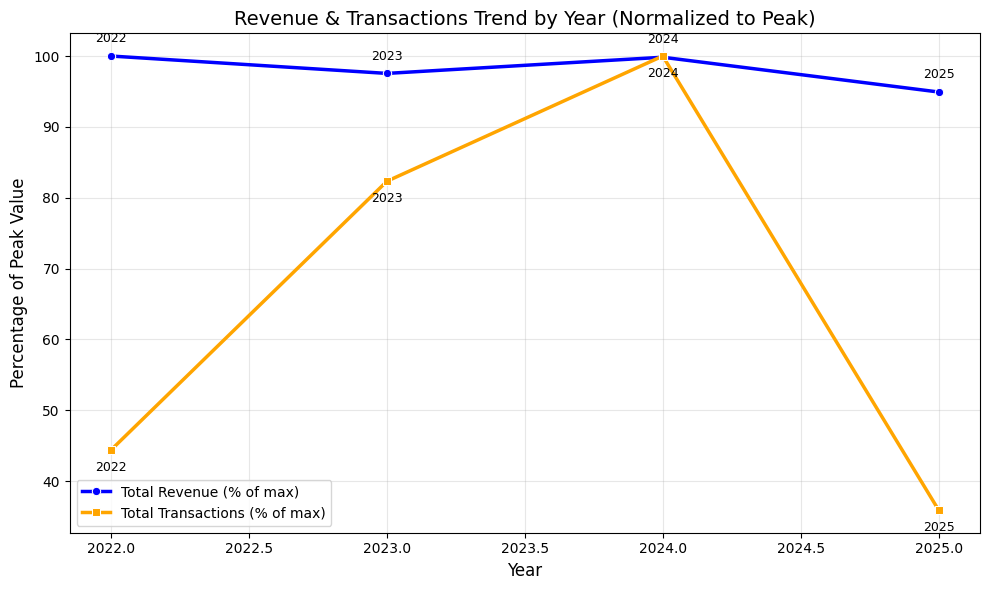

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize both columns to 0-100% of their max for easy comparison
max_revenue = revenue_byyear['Total_revenue'].max()
max_transactions = revenue_byyear['Total_transactions'].max()

revenue_byyear['Revenue_norm'] = (revenue_byyear['Total_revenue'] / max_revenue) * 100
revenue_byyear['Transactions_norm'] = (revenue_byyear['Total_transactions'] / max_transactions) * 100

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=revenue_byyear,
    x='Year',
    y='Revenue_norm',
    marker='o',
    color='blue',
    linewidth=2.5,
    label='Total Revenue (% of max)'
)

sns.lineplot(
    data=revenue_byyear,
    x='Year',
    y='Transactions_norm',
    marker='s',
    color='orange',
    linewidth=2.5,
    label='Total Transactions (% of max)'
)

plt.title('Revenue & Transactions Trend by Year (Normalized to Peak)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Peak Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Add annotations for key years
for x, y1, y2 in zip(revenue_byyear['Year'], revenue_byyear['Revenue_norm'], revenue_byyear['Transactions_norm']):
    plt.annotate(f'{x}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
    plt.annotate(f'{x}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()